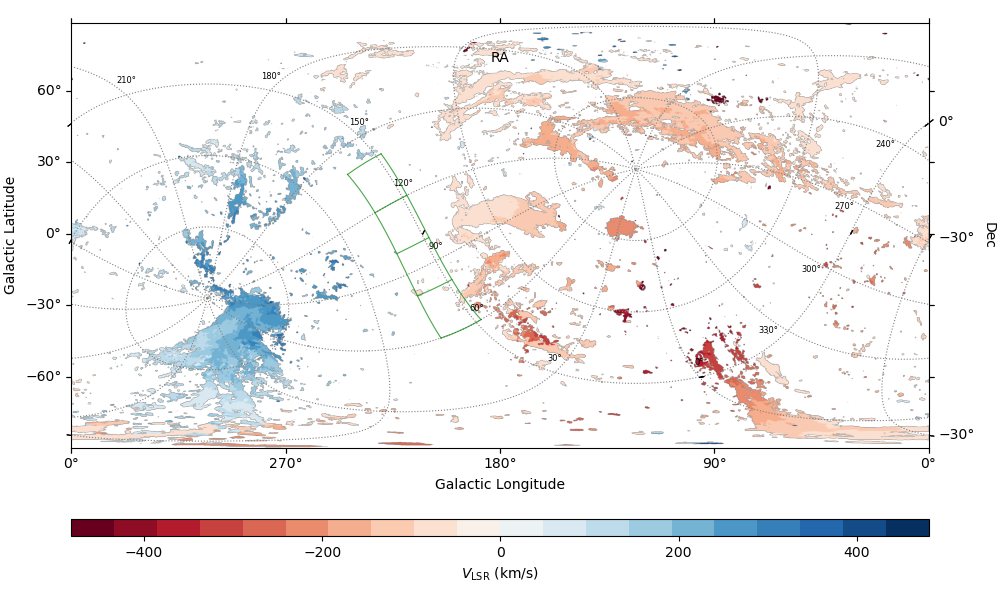

IndexError: index 0 is out of bounds for axis 1 with size 0

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u

# 1. 读入FITS和WCS
hdul = fits.open('hi4pi-hvc-vlsr-gal-car.fits')
wcs = WCS(hdul[0].header)

fig, ax = plt.subplots(figsize=(10, 6), layout="compressed", subplot_kw={"projection": wcs})
cmap = plt.get_cmap("RdBu", 20)
im = ax.imshow(hdul[0].data, origin='lower', cmap=cmap)
ax.set_xlabel("Galactic Longitude")
ax.set_ylabel("Galactic Latitude")

# 2. 定义你要画的 RA/Dec 网格线
# --- RA纵线 ---
dec_range = np.arange(-13, 2.01, 0.01)  # Dec线的跨越范围
for ra in np.arange(60, 141, 20):     # RA每隔10度一条
    ras = np.full_like(dec_range, ra)
    decs = dec_range
    # 把 (RA, Dec) 转换成 Galactic
    sc = SkyCoord(ra=ras*u.deg, dec=decs*u.deg, frame='icrs')
    gal = sc.galactic
    l = gal.l.deg
    b = gal.b.deg
    # 再用WCS把 (l, b) 转成像素
    pix = wcs.all_world2pix(np.array([l, b]).T, 0)
    x, y = pix[:,0], pix[:,1]
    ax.plot(x, y, color='green', lw=0.8, alpha=0.7)

# --- Dec横线 ---
ra_range = np.arange(60, 140.01, 0.01)
for dec in [-13, 2]:
    decs = np.full_like(ra_range, dec)
    ras = ra_range
    sc = SkyCoord(ra=ras*u.deg, dec=decs*u.deg, frame='icrs')
    gal = sc.galactic
    l = gal.l.deg
    b = gal.b.deg
    pix = wcs.all_world2pix(np.array([l, b]).T, 0)
    x, y = pix[:,0], pix[:,1]
    ax.plot(x, y, color='green', lw=0.8, alpha=0.7)

overlay = ax.get_coords_overlay("icrs")
overlay.grid(color="grey", ls="dotted")

overlay["ra"].set_ticks(np.arange(0, 360, 30) * u.deg)
overlay["ra"].set_ticks_position(("const-dec", "t"))
overlay["ra"].set_ticklabel_position(("const-dec", "t"))
overlay["ra"].set_ticklabel(size=6)
overlay["ra"].set_ticks_visible(False)
overlay["ra"].set_axislabel("RA")
overlay["ra"].set_major_formatter("dd")
overlay["dec"].add_tickable_gridline("const-dec", 0 * u.deg)
overlay["dec"].set_axislabel("Dec")

plt.colorbar(im, orientation="horizontal", aspect=50, label=r'$V_{\mathrm{LSR}}\ \mathrm{(km/s)}$')
plt.savefig("area.png", dpi=600, bbox_inches="tight")
plt.show()

In [6]:
overlay.grid

<bound method CoordinatesMap.grid of <CoordinatesMap with 2 world coordinates:

  index aliases    type   unit    wrap    format_unit visible
  ----- ------- --------- ---- ---------- ----------- -------
      0      ra longitude  deg 360d00m00s         deg     yes
      1     dec  latitude  deg       None         deg     yes

>>